# Proyecto: Clasificación de Texto

### Problema a Resolver: ¿Podemos clasificar títulos de noticias sabiendo si son sarcástios/satíricos o no?

## Dataset de Sarcasmo: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection

#### Contexto

Los estudios anteriores sobre detección de sarcasmo utilizan principalmente conjuntos de datos de Twitter recopilados mediante la supervisión basada en hashtags, pero estos conjuntos de datos son ruidosos en términos de etiquetas y lenguaje. Además, muchos tuits son respuestas a otros tuits y detectar sarcasmo en ellos requiere la disponibilidad de tuits contextuales.

Para superar las limitaciones relacionadas con el ruido en los conjuntos de datos de Twitter, este conjunto de datos de titulares de noticias para la detección de sarcasmo se recopila de dos sitios web de noticias;

- The Onion, una pagina de noticias que produce noticias de manera sarcastica (lo que sería ElDeforma en México). 

- HuffPost, sitio de noticias reales con titulos de verdad.

Este conjunto es superior al conjunto de datos de Twitter ya que los titulares de noticias están escritos de manera profesional y muy formal; incluso los de The Onion, para mantener su naturaleza de "parodia". Significa que la precencia de errores ortográficos es nula ni hay uso informal del idioma. 

Otra ventaja es que lso titulares contienen todo el contexto necesario para entenderlos, a diferencia de los tuits que son respuestas a tuits y no cuentan con el contexto necesario para poder entenderlos.

#### Motivación

Prevenir caer en noticias falsas y la distrubución de informacióin falsa.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import re
import os
import string
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.model_selection import train_test_split

nltk (Natural Language Toolkit) es una librería de procesamiento de lenguaje natural (NLP) de Python. 
Ofrece herramientas para pdoer trabajar con NLP:

- Stopwords: Proporciona listas de palabras comunes en varios idiomas (como "el", "la", "de" en español) que se suelen eliminar en tareas de procesamiento de texto para reducir el ruido.

- Tokenización (punkt): Dividir un texto en palabras, oraciones u otras unidades significativas.

- Stemming y lematización (wordnet y own-1.4): Reducir palabras a sus raíces o formas base, lo cual es útil para entender mejor el significado de un texto. WordNet es una base de datos léxica en inglés y su complemento, Open Multilingual WordNet, incluye traducciones y otros recursos multilinguales.

Aquí vamos a descargar los paquetes para trabajar con ellos 

In [3]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\brugi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\brugi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\brugi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\brugi\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
Path = "../Práctica 4/" #Depende de la ruta en tu máquina

In [5]:
os.makedirs(Path+"Sarcasm_Headlines_Dataset", exist_ok=True)

In [6]:
with zipfile.ZipFile('archive.zip', 'r') as archive:
   # Extrae todo el contenido del achivo ZIP en el directorio actual
   archive.extractall("Sarcasm_Headlines_Dataset")

In [7]:
os.listdir(Path)

['.ipynb_checkpoints',
 'archive.zip',
 'Sarcasm_Headlines_Dataset',
 'TF-Sarcasmo-Vacio.ipynb',
 'TF-Sarcasmo.ipynb']

In [8]:
os.listdir(Path + "Sarcasm_Headlines_Dataset")

['.ipynb_checkpoints',
 'Sarcasm_Headlines_Dataset.json',
 'Sarcasm_Headlines_Dataset_v2.json']

### Contenido

Cada registro en el archivo .json tiene 3 atributos:

- is_sarcastic : 1 si el registro es sarcástico, 0 si el registro es no sarcástico

- headline : El título del artículo de noticias

- article_link: Enlace al artículo de noticias original.

In [58]:
df = pd.read_json(Path + "Sarcasm_Headlines_Dataset/Sarcasm_Headlines_Dataset.json", lines=True)
df = df[['headline', 'is_sarcastic', 'article_link']]
df.head()

,headline,is_sarcastic,article_link
0,former versace store clerk sues over secret 'b...,0,https://www.huffingtonpost.com/entry/versace-b...
1,the 'roseanne' revival catches up to our thorn...,0,https://www.huffingtonpost.com/entry/roseanne-...
2,mom starting to fear son's web series closest ...,1,https://local.theonion.com/mom-starting-to-fea...
3,"boehner just wants wife to listen, not come up...",1,https://politics.theonion.com/boehner-just-wan...
4,j.k. rowling wishes snape happy birthday in th...,0,https://www.huffingtonpost.com/entry/jk-rowlin...


In [10]:
# check for columns with null values
df["is_sarcastic"].isnull().any() # no missing values in is_sarcastic column
df.headline.isnull().any() # no missing values in headline column 

False

In [11]:
df['headline_count'] = df.headline.apply(lambda x: len(list(x.split())))
df['headline_unique_word_count'] = df.headline.apply(lambda x: len(set(x.split())))
df['headline_has_digits'] = df.headline.apply(lambda x: bool(re.search(r'\d', x)))
df

,headline,is_sarcastic,article_link,headline_count,headline_unique_word_count,headline_has_digits
0,former versace store clerk sues over secret 'b...,0,https://www.huffingtonpost.com/entry/versace-b...,12,12,False
1,the 'roseanne' revival catches up to our thorn...,0,https://www.huffingtonpost.com/entry/roseanne-...,14,14,False
2,mom starting to fear son's web series closest ...,1,https://local.theonion.com/mom-starting-to-fea...,14,13,False
3,"boehner just wants wife to listen, not come up...",1,https://politics.theonion.com/boehner-just-wan...,13,13,False
4,j.k. rowling wishes snape happy birthday in th...,0,https://www.huffingtonpost.com/entry/jk-rowlin...,11,11,False
...,...,...,...,...,...,...
26704,american politics in moral free-fall,0,https://www.huffingtonpost.com/entry/american-...,5,5,False
26705,america's best 20 hikes,0,https://www.huffingtonpost.com/entry/americas-...,4,4,True
26706,reparations and obama,0,https://www.huffingtonpost.com/entry/reparatio...,3,3,False
26707,israeli ban targeting boycott supporters raise...,0,https://www.huffingtonpost.com/entry/israeli-b...,8,8,False


- Puntuación: Porque no sabe lidiar con eso '\[[^]]*\]'

- Caracterse especiales: remover letras que no estén en el idoma

- Lematización: cambiar palabras en tercera persona a primera persona, cambiar palabras en pasado y futuro a presente, poner todo en raíz

- Stop words: artículos, preposiciones, pronombres

In [12]:
#Removing punctiation marks
def remove_punctuations(text):
    return re.sub('\[[^]]*\]', '', text)

#Removing special characters
def remove_specialchars(text):
    return re.sub("[^a-zA-Z0-9]"," ",text)

#Removal of stopwords and lemmatization
def remove_stopwords_and_lemmatization(text):
    final_text = []
    text = text.lower() #convert all words into lowercase
    text = nltk.word_tokenize(text)
    
    for word in text:
        if word not in set(stopwords.words('english')):
            lemma = nltk.WordNetLemmatizer()
            word = lemma.lemmatize(word) 
            final_text.append(word)
    return " ".join(final_text)


#Total function
def cleaning(text):
    text = remove_punctuations(text)
    text = remove_specialchars(text)
    text = remove_stopwords_and_lemmatization(text)
    return text

df['headline']=df['headline'].apply(cleaning)

In [13]:
df.head()

,headline,is_sarcastic,article_link,headline_count,headline_unique_word_count,headline_has_digits
0,former versace store clerk sue secret black co...,0,https://www.huffingtonpost.com/entry/versace-b...,12,12,False
1,roseanne revival catch thorny political mood b...,0,https://www.huffingtonpost.com/entry/roseanne-...,14,14,False
2,mom starting fear son web series closest thing...,1,https://local.theonion.com/mom-starting-to-fea...,14,13,False
3,boehner want wife listen come alternative debt...,1,https://politics.theonion.com/boehner-just-wan...,13,13,False
4,j k rowling wish snape happy birthday magical way,0,https://www.huffingtonpost.com/entry/jk-rowlin...,11,11,False


In [14]:
df['headline_count'] = df.headline.apply(lambda x: len(list(x.split())))
df['headline_unique_word_count'] = df.headline.apply(lambda x: len(set(x.split())))
df['headline_has_digits'] = df.headline.apply(lambda x: bool(re.search(r'\d', x)))
df

,headline,is_sarcastic,article_link,headline_count,headline_unique_word_count,headline_has_digits
0,former versace store clerk sue secret black co...,0,https://www.huffingtonpost.com/entry/versace-b...,10,10,False
1,roseanne revival catch thorny political mood b...,0,https://www.huffingtonpost.com/entry/roseanne-...,8,8,False
2,mom starting fear son web series closest thing...,1,https://local.theonion.com/mom-starting-to-fea...,9,9,False
3,boehner want wife listen come alternative debt...,1,https://politics.theonion.com/boehner-just-wan...,9,9,False
4,j k rowling wish snape happy birthday magical way,0,https://www.huffingtonpost.com/entry/jk-rowlin...,9,9,False
...,...,...,...,...,...,...
26704,american politics moral free fall,0,https://www.huffingtonpost.com/entry/american-...,5,5,False
26705,america best 20 hike,0,https://www.huffingtonpost.com/entry/americas-...,4,4,True
26706,reparation obama,0,https://www.huffingtonpost.com/entry/reparatio...,2,2,False
26707,israeli ban targeting boycott supporter raise ...,0,https://www.huffingtonpost.com/entry/israeli-b...,8,8,False


Algunos análisis previos que podemos hacer a los datos son los siguientes:

- ¿Cuáles son las frecuencias de los titulares sarcásticos en comparación con los titulares no sarcásticos?

- ¿Cuál es la longitud de las palabras de los titulares? ¿Para los titulares sarcástics y no sarcásticos?

- ¿Los titulares sarcásticos utilizan estadísticas (dígitos/números) en su redacción? ¿En comparación con los titulares no sarcásticos?

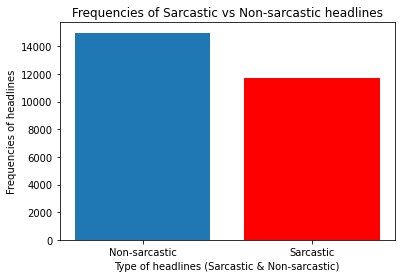

Non-sarcastic    0.56
Sarcastic        0.44
Name: headline_count, dtype: float64

In [15]:
sarcastic_dat = df.groupby('is_sarcastic').count()
sarcastic_dat.index = ['Non-sarcastic','Sarcastic']
plt.xlabel('Type of headlines (Sarcastic & Non-sarcastic)')
plt.ylabel('Frequencies of headlines')
plt.xticks(fontsize=10)
plt.title('Frequencies of Sarcastic vs Non-sarcastic headlines')
bar_graph = plt.bar(sarcastic_dat.index, sarcastic_dat.headline_count)
bar_graph[1].set_color('r')
plt.show()

round(sarcastic_dat.headline_count / sarcastic_dat.headline_count.sum(), 2)

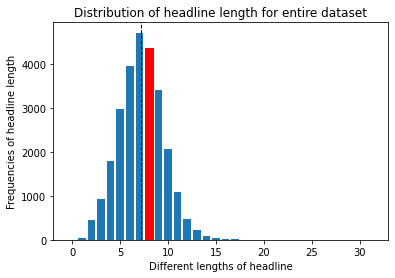

In [16]:
all_dat = df.groupby('headline_count').count()
sarcastic_dat1 = df[df.is_sarcastic==1]
sarcastic_dat = sarcastic_dat1.groupby('headline_count').count()
not_sarcastic_dat1 = df[df.is_sarcastic==0]
not_sarcastic_dat = not_sarcastic_dat1.groupby('headline_count').count()

plt.xlabel('Different lengths of headline')
plt.ylabel('Frequencies of headline length')
plt.xticks(fontsize=10)
plt.title('Distribution of headline length for entire dataset')
bar_graph = plt.bar(all_dat.index, all_dat.headline)
bar_graph[8].set_color('r')
plt.axvline(df.headline_count.mean(), color='k', linestyle='dashed', linewidth=1)  # median is 10 words in a headline
plt.show()

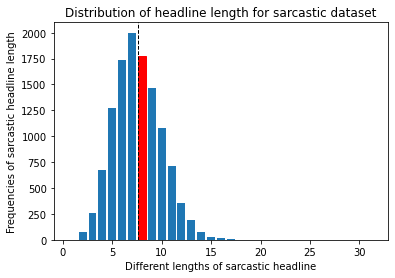

In [17]:
plt.xlabel('Different lengths of sarcastic headline')
plt.ylabel('Frequencies of sarcastic headline length')
plt.xticks(fontsize=10)
plt.title('Distribution of headline length for sarcastic dataset')
bar_graph = plt.bar(sarcastic_dat.index, sarcastic_dat.headline)
bar_graph[7].set_color('r')
plt.axvline(sarcastic_dat1.headline_count.mean(), color='k', linestyle='dashed', linewidth=1)  # median is 10 words in a headline
plt.show()

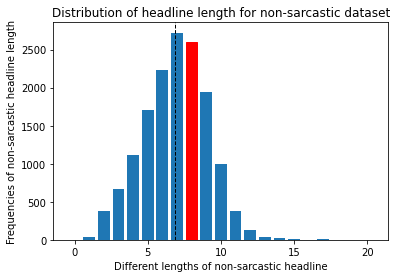

In [18]:
plt.xlabel('Different lengths of non-sarcastic headline')
plt.ylabel('Frequencies of non-sarcastic headline length')
plt.xticks(fontsize=10)
plt.title('Distribution of headline length for non-sarcastic dataset')
bar_graph = plt.bar(not_sarcastic_dat.index, not_sarcastic_dat.headline)
bar_graph[8].set_color('r')
plt.axvline(not_sarcastic_dat1.headline_count.mean(), color='k', linestyle='dashed', linewidth=1)  # median is 10 words in a headline
plt.show()

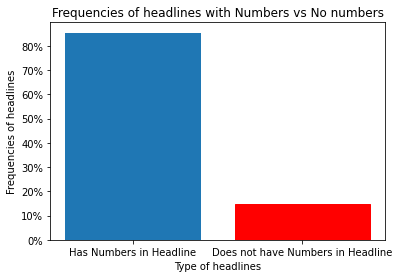

In [19]:
digits_dat = df.groupby('headline_has_digits').count()
digits_dat.index = ['Has Numbers in Headline','Does not have Numbers in Headline']


plt.xlabel('Type of headlines')
plt.ylabel('Frequencies of headlines')
plt.xticks(fontsize=10)
plt.title('Frequencies of headlines with Numbers vs No numbers')
bar_graph = plt.bar(digits_dat.index, digits_dat.headline / digits_dat.headline_count.sum())
bar_graph[1].set_color('r')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

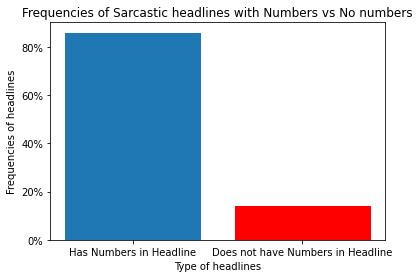

In [20]:
sarcastic_digits_dat = df[df.is_sarcastic==1].groupby('headline_has_digits').count()
sarcastic_digits_dat.index = ['Has Numbers in Headline','Does not have Numbers in Headline']


plt.xlabel('Type of headlines')
plt.ylabel('Frequencies of headlines')
plt.xticks(fontsize=10)
plt.title('Frequencies of Sarcastic headlines with Numbers vs No numbers')
bar_graph = plt.bar(sarcastic_digits_dat.index, sarcastic_digits_dat.headline / sarcastic_digits_dat.headline_count.sum())
bar_graph[1].set_color('r')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

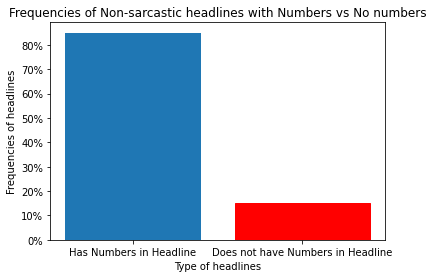

Has Numbers in Headline              0.85
Does not have Numbers in Headline    0.15
Name: headline, dtype: float64
Has Numbers in Headline              0.86
Does not have Numbers in Headline    0.14
Name: headline, dtype: float64
Has Numbers in Headline              0.85
Does not have Numbers in Headline    0.15
Name: headline, dtype: float64


In [21]:
not_sarcastic_digits_dat = df[df.is_sarcastic==0].groupby('headline_has_digits').count()
not_sarcastic_digits_dat.index = ['Has Numbers in Headline','Does not have Numbers in Headline']


plt.xlabel('Type of headlines')
plt.ylabel('Frequencies of headlines')
plt.xticks(fontsize=10)
plt.title('Frequencies of Non-sarcastic headlines with Numbers vs No numbers')
bar_graph = plt.bar(not_sarcastic_digits_dat.index, not_sarcastic_digits_dat.headline / not_sarcastic_digits_dat.headline_count.sum())
bar_graph[1].set_color('r')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

print(round(digits_dat.headline / digits_dat.headline_count.sum(),2))
print(round(sarcastic_digits_dat.headline / sarcastic_digits_dat.headline_count.sum(),2))
print(round(not_sarcastic_digits_dat.headline / not_sarcastic_digits_dat.headline_count.sum(),2))

In [22]:
text = " ".join(review for review in df.headline)
print ("There are {} words in the combination of all review.".format(len(text)))

There are 1304276 words in the combination of all review.


In [23]:
train_data, test_data = train_test_split(df[['headline', 'is_sarcastic']], test_size=0.1)  # randomly splitting 10% of dataset to be training dataset 

training_sentences = list(train_data['headline'])
training_labels = list(train_data['is_sarcastic'])

testing_sentences = list(test_data['headline'])
testing_labels = list(test_data['is_sarcastic'])
training_labels_final = np.array(training_labels)
testing_labels_final = np.array(testing_labels)

In [24]:
import tensorflow as tf
from tensorflow import keras
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
from tensorflow.keras.layers import Dense, GRU, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

Esta parte del código se encarga de preparar los datos de texto para el entrenamiento de un modelo al convertir los textos en secuencias numéricas y asegurarse de que todas las secuencias tengan una longitud uniforme. Esto es esencial para que el modelo pueda manejar las entradas de texto de manera efectiva.

- El vocab_size: Define el tamaño del vocabulario, limitando el modelo a las 10,000 palabras más frecuentes en los datos.

- El embedding_dim: Especifica la dimensión del espacio de embedding. En otras palabras, es el tamaño de los vectores que se utilizarán para representar cada palabra en el vocabulario. Cada palabra se representará como un vector de 16 valores numéricos continuos.

- El max_length: Define la longitud máxima de las secuencias de texto. Si un texto es más largo, se truncará; si es más corto, se rellenará.

- El trunc_type='post': Indica que si una secuencia de texto es más larga que max_length, se truncará desde el final 

- El tokenizer es una herramienta utilizada en el procesamiento de texto para convertir secuencias de palabras en secuencias de enteros.

- El fit_on_texts ajusta el tokenizador a las oraciones de entrenamiento para construir un índice de palabras.

- El word_index contiene un diccionario que asigna un índice único a cada palabra en el vocabulario.

- El texts_to_sequences convierte las oraciones en secuencias de enteros basadas en el índice de palabras.

- El pad_sequences asegura que todas las secuencias tengan la misma longitud (max_length). Las secuencias más cortas se rellenan con ceros y las más largas se truncan según trunc_type.

In [25]:
#Define el tamaño del vocabulario, limitando el modelo a las 10,000 palabras más frecuentes en los datos.
vocab_size = 10000   
embedding_dim = 16
max_length = 120
trunc_type='post'

tokenizer = Tokenizer(num_words = vocab_size)
tokenizer.fit_on_texts(training_sentences)

word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(training_sentences)
padded = pad_sequences(sequences, maxlen=max_length, truncating=trunc_type)

testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences,maxlen=max_length)


### Ejemplo

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(["I love machine learning", "Machine learning is fun"])

word_index = tokenizer.word_index

{'machine': 1, 'learning': 2, 'i': 3, 'love': 4, 'is': 5, 'fun': 6}

sequences = tokenizer.texts_to_sequences(["I love machine learning"])
[[3, 4, 1, 2]]

padded = pad_sequences(sequences, maxlen, truncating)
[[0, 0, 0, 0, 3, 4, 1, 2, 0, 0]]

## RNN + GRU + Regularización Lasso (L1)

GRU es un tipo de neurona especial que va a guardar infomración. Va a permitir las conexiónes recurrentes. Utilizan 2 tipos de neuronas; gru y lstm.

Entre más capas tiene una red, se hace mayor la probabilidad de unos problemas; el gradiente se hace 0 o se va al infinito. 

Son especiales ya que almacenan información de los gradientes antes de la derivada. Lo van conservando (pasando) a las siguiente unidades o lo va desgastando de una forma menor.

- La primera capa onvierte los índices de las palabras en vectores densos de tamaño embedding_dim

- La capa GRU (Gated Recurrent Unit) es una celda recurrente que se utiliza para manejar secuencias de datos y mantener dependencias a largo plazo. Procesa datos secuenciales y mantiene una memoria interna que se actualiza con cada paso de tiempo. Guarda los pesos que mejor le han servido, lo evaúlua y decide si ese peso debe conservarse o reiniciarlo para calcularlo de nuevo y mejorarlo.

- La capa GRU está envuelta en una capa Bidirectional, lo que significa que el modelo procesa la secuencia en ambas direcciones (de adelante hacia atrás y de atrás hacia adelante), mejorando así la comprensión del contexto en ambas direcciones.

- La capa densa con 100 unidades y activación ReLU, con regularización L1 aplicada a los pesos. Esta normalización, a la hora de calcular los pesos de la red, agrega una penalización basada en la suma de los valores absolutos de los coeficientes de los parámetros del modelo. Fomenta la simplicidad y la sparsidad en el modelo, ayudando a prevenir el sobreajuste y a realizar una selección de características implícita. Elimina atributos de entrada irrelevantes. 

- La siguiente capa normaliza las salidas de la capa anterior para mejorar la estabilidad del entrenamiento y acelerar el proceso de aprendizaje.

- La capa Dropout aplica una tasa de abandono del 50% durante el entrenamiento para evitar el sobreajuste al "apagar" aleatoriamente un porcentaje de las neuronas durante cada época de entrenamiento.

- La capa de salida tiene una sola unidad con activación sigmoide, lo que produce una probabilidad entre 0 y 1 para la clasificación binaria (sarcasmo vs. no sarcasmo).

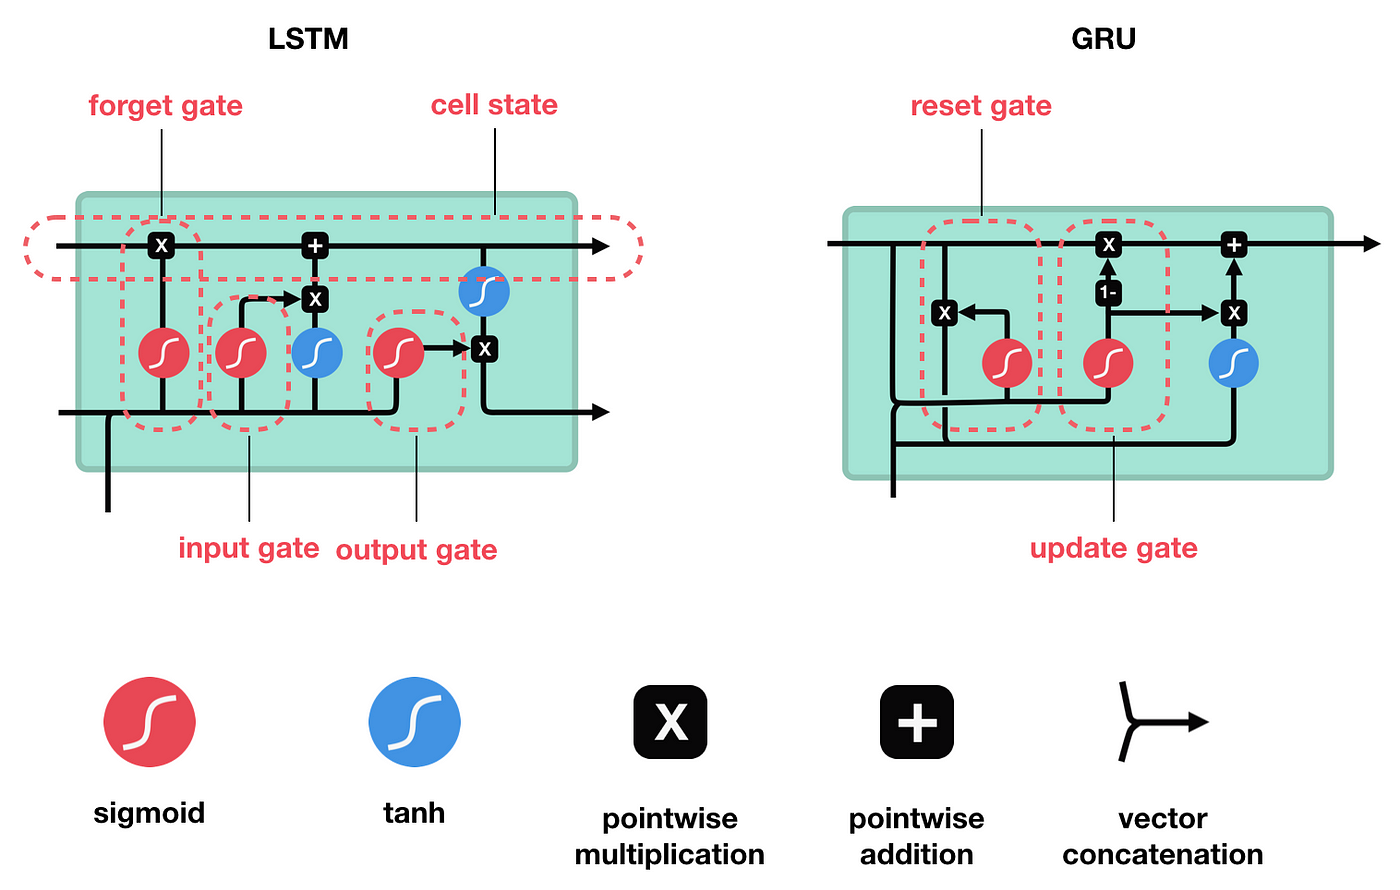

In [26]:
# Model Definition with BiRNN (GRU)
# with L1 Lasso Regularization, for feature selection
# Dropout, for robustness of recurrent neural networks
# Batch Normalization, to stabilize and perhaps accelerate the learning process

model_gru_l1 = keras.Sequential([
    keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    keras.layers.Bidirectional(keras.layers.GRU(32)),
    keras.layers.Dense(50, kernel_regularizer=keras.regularizers.l1(0.007), activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, kernel_regularizer=keras.regularizers.l1(0.007), activation='sigmoid')
])
model_gru_l1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model_gru_l1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 120, 16)           160000    
                                                                 
 bidirectional (Bidirectiona  (None, 64)               9600      
 l)                                                              
                                                                 
 dense (Dense)               (None, 50)                3250      
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 172,901
Trainable params: 172,901
Non-trainable params: 0
__________________________________________________

In [27]:
num_epochs = 5

early_stopping = EarlyStopping(monitor='val_loss', patience=2)

history_gru_l1 = model_gru_l1.fit(
                    padded, 
                    training_labels_final, 
                    epochs=num_epochs, 
                    batch_size=256, 
                    validation_data=(testing_padded, testing_labels_final),
                    callbacks=[early_stopping]
                    )

Epoch 1/5
94/94 [==============================] - 9s 30ms/step - loss: 2.3518 - accuracy: 0.5681 - val_loss: 1.5305 - val_accuracy: 0.6342
Epoch 2/5
94/94 [==============================] - 2s 19ms/step - loss: 0.9958 - accuracy: 0.7843 - val_loss: 0.6634 - val_accuracy: 0.8008
Epoch 3/5
94/94 [==============================] - 2s 18ms/step - loss: 0.5361 - accuracy: 0.8603 - val_loss: 0.5733 - val_accuracy: 0.8016
Epoch 4/5
94/94 [==============================] - 2s 18ms/step - loss: 0.4558 - accuracy: 0.8924 - val_loss: 0.5790 - val_accuracy: 0.7967
Epoch 5/5
94/94 [==============================] - 2s 18ms/step - loss: 0.4128 - accuracy: 0.9143 - val_loss: 0.6017 - val_accuracy: 0.7971


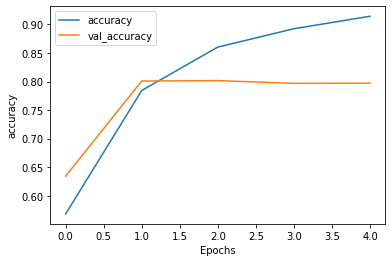

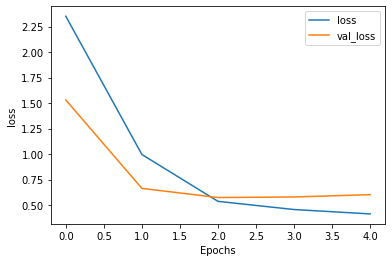

In [28]:
def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()

plot_graphs(history_gru_l1, 'accuracy')
plot_graphs(history_gru_l1, 'loss')
plt.show()

## Probar RNN + GRU + Regularización Lasso (L1)

In [29]:
# Cargar el archivo JSON
df_gru_l1 = pd.read_json(Path + "Sarcasm_Headlines_Dataset/Sarcasm_Headlines_Dataset_v2.json", lines=True)

# Aplicar limpieza a los titulares
df_gru_l1['headline'] = df_gru_l1['headline'].apply(cleaning)

# Convertir los titulares limpiados en secuencias y aplicar padding
sequences_gru_l1 = tokenizer.texts_to_sequences(df_gru_l1['headline'])
padded_gru_l1 = pad_sequences(sequences_gru_l1, maxlen=max_length, truncating=trunc_type)

In [30]:
# Hacer predicciones
predictions_gru_l1 = model_gru_l1.predict(padded_gru_l1)

895/895 [==============================] - 6s 6ms/step


In [31]:
# Convertir las predicciones en etiquetas binarizadas (0 o 1)
predicted_labels = (predictions_gru_l1 > 0.5).astype(int)

# Añadir las predicciones al DataFrame original para visualización
df_gru_l1['predicted_is_sarcastic'] = predicted_labels

# Mostrar algunas filas con los titulares y las predicciones
print(df_gru_l1[['headline', 'predicted_is_sarcastic', 'is_sarcastic']].head())

                                            headline  predicted_is_sarcastic  \
0  thirtysomething scientist unveil doomsday cloc...                       1   
1  dem rep totally nail congress falling short ge...                       0   
2          eat veggie 9 deliciously different recipe                       0   
3       inclement weather prevents liar getting work                       1   
4  mother come pretty close using word streaming ...                       1   

   is_sarcastic  
0             1  
1             0  
2             0  
3             1  
4             1  


## RNN + GRU + Regularización Ridge (L2)

A diferencia de la regularización L1, la L2 agrega una penalización a la función de pérdida que se basa en la suma de los cuadrados de los coeficientes del modelo. Reduce el tamaño de todos los coeficientes, evitando que se vuelvan demasiado grandes, lo que ayuda a suavizar el modelo y a prevenir el sobreajuste.

In [32]:
model_gru_l2 = keras.Sequential([
    keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    keras.layers.Bidirectional(keras.layers.GRU(32)),
    keras.layers.Dense(100, kernel_regularizer=keras.regularizers.l2(0.007), activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, kernel_regularizer=keras.regularizers.l2(0.007), activation='sigmoid')
])
model_gru_l2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model_gru_l2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 120, 16)           160000    
                                                                 
 bidirectional_1 (Bidirectio  (None, 64)               9600      
 nal)                                                            
                                                                 
 dense_2 (Dense)             (None, 100)               6500      
                                                                 
 dropout_1 (Dropout)         (None, 100)               0         
                                                                 
 dense_3 (Dense)             (None, 1)                 101       
                                                                 
Total params: 176,201
Trainable params: 176,201
Non-trainable params: 0
________________________________________________

In [33]:
num_epochs = 5
history_gru_l2 = model_gru_l2.fit(
                    padded, 
                    training_labels_final, 
                    epochs=num_epochs, 
                    batch_size=256, 
                    validation_data=(testing_padded, testing_labels_final)
                    )

Epoch 1/5
94/94 [==============================] - 5s 29ms/step - loss: 0.9586 - accuracy: 0.5684 - val_loss: 0.7339 - val_accuracy: 0.6683
Epoch 2/5
94/94 [==============================] - 2s 20ms/step - loss: 0.5299 - accuracy: 0.7951 - val_loss: 0.4989 - val_accuracy: 0.7956
Epoch 3/5
94/94 [==============================] - 2s 18ms/step - loss: 0.3601 - accuracy: 0.8699 - val_loss: 0.4677 - val_accuracy: 0.8046
Epoch 4/5
94/94 [==============================] - 2s 18ms/step - loss: 0.2967 - accuracy: 0.8979 - val_loss: 0.4929 - val_accuracy: 0.8004
Epoch 5/5
94/94 [==============================] - 2s 18ms/step - loss: 0.2569 - accuracy: 0.9175 - val_loss: 0.5333 - val_accuracy: 0.8001


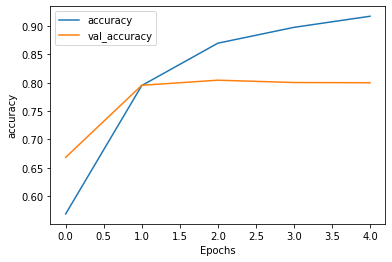

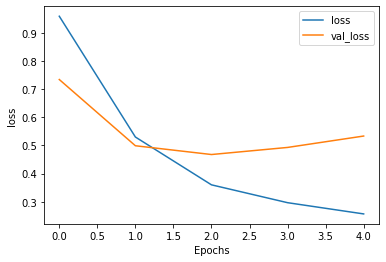

In [34]:
plot_graphs(history_gru_l2, 'accuracy')
plot_graphs(history_gru_l2, 'loss')
plt.show()

## Probar RNN + GRU + Regularización Ridge (L2)

In [35]:
# Cargar el archivo JSON
df_gru_l2 = pd.read_json(Path + "Sarcasm_Headlines_Dataset/Sarcasm_Headlines_Dataset_v2.json", lines=True)

# Aplicar limpieza a los titulares
df_gru_l2['headline'] = df_gru_l2['headline'].apply(cleaning)

# Convertir los titulares limpiados en secuencias y aplicar padding
sequences_gru_l2 = tokenizer.texts_to_sequences(df_gru_l2['headline'])
padded_gru_l2 = pad_sequences(sequences_gru_l2, maxlen=max_length, truncating=trunc_type)

In [36]:
# Hacer predicciones
predictions_gru_l2 = model_gru_l2.predict(padded_gru_l2)

895/895 [==============================] - 6s 6ms/step


In [37]:
# Convertir las predicciones en etiquetas binarizadas (0 o 1)
predicted_labels = (predictions_gru_l2 > 0.5).astype(int)

# Añadir las predicciones al DataFrame original para visualización
df_gru_l2['predicted_is_sarcastic'] = predicted_labels

# Mostrar algunas filas con los titulares y las predicciones
print(df_gru_l2[['headline', 'predicted_is_sarcastic', 'is_sarcastic']].head())

                                            headline  predicted_is_sarcastic  \
0  thirtysomething scientist unveil doomsday cloc...                       1   
1  dem rep totally nail congress falling short ge...                       0   
2          eat veggie 9 deliciously different recipe                       0   
3       inclement weather prevents liar getting work                       1   
4  mother come pretty close using word streaming ...                       1   

   is_sarcastic  
0             1  
1             0  
2             0  
3             1  
4             1  


## RNN + LSTM + Regularización Lasso (L1)

Ahora en vez de usar una capa GRU, usaremos una capa de Long Short-Term Memory (LSTM): un peso en la memoria de corto plazo que estará actualizando en cada iteración. Un peso a largo plazo que se estará guardando en cada iteración, es el mejor peso de la memoria a corto plazo que ha servido, y un peso que debe ser olvidado ya que no ayudó al entrenamiento. 

In [38]:
model_lstm_l1 = keras.Sequential([
    keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    keras.layers.Bidirectional(keras.layers.LSTM(32)),
    keras.layers.Dense(100, kernel_regularizer=keras.regularizers.l1(0.007), activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, kernel_regularizer=keras.regularizers.l1(0.007), activation='sigmoid')
])

model_lstm_l1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model_lstm_l1.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 120, 16)           160000    
                                                                 
 bidirectional_2 (Bidirectio  (None, 64)               12544     
 nal)                                                            
                                                                 
 dense_4 (Dense)             (None, 100)               6500      
                                                                 
 dropout_2 (Dropout)         (None, 100)               0         
                                                                 
 dense_5 (Dense)             (None, 1)                 101       
                                                                 
Total params: 179,145
Trainable params: 179,145
Non-trainable params: 0
________________________________________________

In [39]:
num_epochs = 5
history_lstm_l1 = model_lstm_l1.fit(
                    padded, 
                    training_labels_final, 
                    epochs=num_epochs, 
                    batch_size=256, 
                    validation_data=(testing_padded, testing_labels_final)
                    )

Epoch 1/5
94/94 [==============================] - 6s 31ms/step - loss: 3.2789 - accuracy: 0.5612 - val_loss: 1.8262 - val_accuracy: 0.5608
Epoch 2/5
94/94 [==============================] - 2s 21ms/step - loss: 1.0810 - accuracy: 0.6529 - val_loss: 0.7017 - val_accuracy: 0.6952
Epoch 3/5
94/94 [==============================] - 2s 20ms/step - loss: 0.6091 - accuracy: 0.8113 - val_loss: 0.5903 - val_accuracy: 0.7948
Epoch 4/5
94/94 [==============================] - 2s 20ms/step - loss: 0.5139 - accuracy: 0.8654 - val_loss: 0.5811 - val_accuracy: 0.7918
Epoch 5/5
94/94 [==============================] - 2s 20ms/step - loss: 0.4652 - accuracy: 0.8895 - val_loss: 0.5775 - val_accuracy: 0.7960


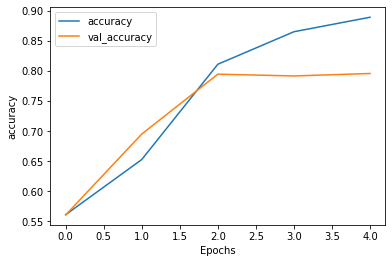

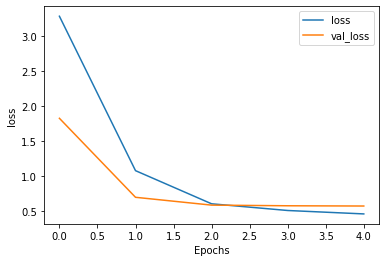

In [40]:
plot_graphs(history_lstm_l1, 'accuracy')
plot_graphs(history_lstm_l1, 'loss')
plt.show()

## Probando RNN + LSTM + Regularización Lasso (L1)

In [41]:
# Cargar el archivo JSON
df_lstm_l1 = pd.read_json(Path + "Sarcasm_Headlines_Dataset/Sarcasm_Headlines_Dataset_v2.json", lines=True)

# Aplicar limpieza a los titulares
df_lstm_l1['headline'] = df_lstm_l1['headline'].apply(cleaning)

# Convertir los titulares limpiados en secuencias y aplicar padding
sequences_lstm_l1 = tokenizer.texts_to_sequences(df_lstm_l1['headline'])
padded_lstm_l1 = pad_sequences(sequences_lstm_l1, maxlen=max_length, truncating=trunc_type)

In [42]:
# Hacer predicciones
predictions_lstm_l1 = model_lstm_l1.predict(padded_lstm_l1)

895/895 [==============================] - 7s 7ms/step


In [43]:
# Convertir las predicciones en etiquetas binarizadas (0 o 1)
predicted_labels = (predictions_lstm_l1 > 0.5).astype(int)

# Añadir las predicciones al DataFrame original para visualización
df_lstm_l1['predicted_is_sarcastic'] = predicted_labels

# Mostrar algunas filas con los titulares y las predicciones
print(df_lstm_l1[['headline', 'predicted_is_sarcastic', 'is_sarcastic']].head())

                                            headline  predicted_is_sarcastic  \
0  thirtysomething scientist unveil doomsday cloc...                       1   
1  dem rep totally nail congress falling short ge...                       0   
2          eat veggie 9 deliciously different recipe                       0   
3       inclement weather prevents liar getting work                       0   
4  mother come pretty close using word streaming ...                       1   

   is_sarcastic  
0             1  
1             0  
2             0  
3             1  
4             1  


## RNN + LSTM + Regularización Ridge (L2)

In [44]:
model_lstm_l2 = keras.Sequential([
    keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    keras.layers.Bidirectional(keras.layers.LSTM(32)),
    keras.layers.Dense(100, kernel_regularizer=keras.regularizers.l2(0.007), activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, kernel_regularizer=keras.regularizers.l2(0.007), activation='sigmoid')
])

model_lstm_l2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model_lstm_l2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 120, 16)           160000    
                                                                 
 bidirectional_3 (Bidirectio  (None, 64)               12544     
 nal)                                                            
                                                                 
 dense_6 (Dense)             (None, 100)               6500      
                                                                 
 dropout_3 (Dropout)         (None, 100)               0         
                                                                 
 dense_7 (Dense)             (None, 1)                 101       
                                                                 
Total params: 179,145
Trainable params: 179,145
Non-trainable params: 0
________________________________________________

In [45]:
num_epochs = 5
history_lstm_l2 = model_lstm_l2.fit(
                    padded, 
                    training_labels_final, 
                    epochs=num_epochs, 
                    batch_size=256, 
                    validation_data=(testing_padded, testing_labels_final)
                    )

Epoch 1/5
94/94 [==============================] - 6s 35ms/step - loss: 0.9491 - accuracy: 0.5840 - val_loss: 0.7247 - val_accuracy: 0.6496
Epoch 2/5
94/94 [==============================] - 2s 23ms/step - loss: 0.5159 - accuracy: 0.8088 - val_loss: 0.4807 - val_accuracy: 0.7978
Epoch 3/5
94/94 [==============================] - 2s 21ms/step - loss: 0.3650 - accuracy: 0.8698 - val_loss: 0.4864 - val_accuracy: 0.7926
Epoch 4/5
94/94 [==============================] - 2s 21ms/step - loss: 0.3059 - accuracy: 0.8957 - val_loss: 0.5088 - val_accuracy: 0.7941
Epoch 5/5
94/94 [==============================] - 2s 23ms/step - loss: 0.2756 - accuracy: 0.9103 - val_loss: 0.5242 - val_accuracy: 0.7937


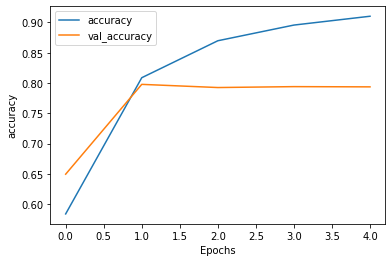

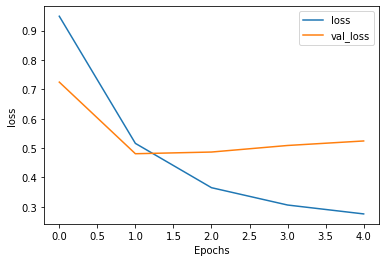

In [48]:
plot_graphs(history_lstm_l2, 'accuracy')
plot_graphs(history_lstm_l2, 'loss')
plt.show()

## Probando RNN + LSTM + Regularización Ridge (L2)

In [47]:
# Cargar el archivo JSON
df_lstm_l2 = pd.read_json(Path + "Sarcasm_Headlines_Dataset/Sarcasm_Headlines_Dataset_v2.json", lines=True)

# Aplicar limpieza a los titulares
df_lstm_l2['headline'] = df_lstm_l2['headline'].apply(cleaning)

# Convertir los titulares limpiados en secuencias y aplicar padding
sequences_lstm_l2 = tokenizer.texts_to_sequences(df_lstm_l2['headline'])
padded_lstm_l2 = pad_sequences(sequences_lstm_l2, maxlen=max_length, truncating=trunc_type)

In [49]:
# Hacer predicciones
predictions_lstm_l2 = model_lstm_l2.predict(padded_lstm_l2)

895/895 [==============================] - 7s 7ms/step


In [50]:
# Convertir las predicciones en etiquetas binarizadas (0 o 1)
predicted_labels = (predictions_lstm_l2 > 0.5).astype(int)

# Añadir las predicciones al DataFrame original para visualización
df_lstm_l2['predicted_is_sarcastic'] = predicted_labels

# Mostrar algunas filas con los titulares y las predicciones
print(df_lstm_l2[['headline', 'predicted_is_sarcastic', 'is_sarcastic']].head())

                                            headline  predicted_is_sarcastic  \
0  thirtysomething scientist unveil doomsday cloc...                       1   
1  dem rep totally nail congress falling short ge...                       0   
2          eat veggie 9 deliciously different recipe                       0   
3       inclement weather prevents liar getting work                       1   
4  mother come pretty close using word streaming ...                       1   

   is_sarcastic  
0             1  
1             0  
2             0  
3             1  
4             1  


- RNN + GRU + L1: 0.7971
- RNN + GRU + L2: 0.8001
- RNN + LSTM + L1: 0.7960
- RNN + LSTM + L2: 0.7937